In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import matplotlib.dates as mdates

from datetime import date
from dateutil.relativedelta import relativedelta

In [2]:
df_train = pd.read_csv('DailyDelhiClimateTrain.csv')
df_test = pd.read_csv('DailyDelhiClimateTest.csv')

In [3]:
df_train.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [4]:
df_train['date'] = pd.to_datetime(df_train['date']) #convert to datetime
df_test['date'] = pd.to_datetime(df_test['date']) #convert to datetime

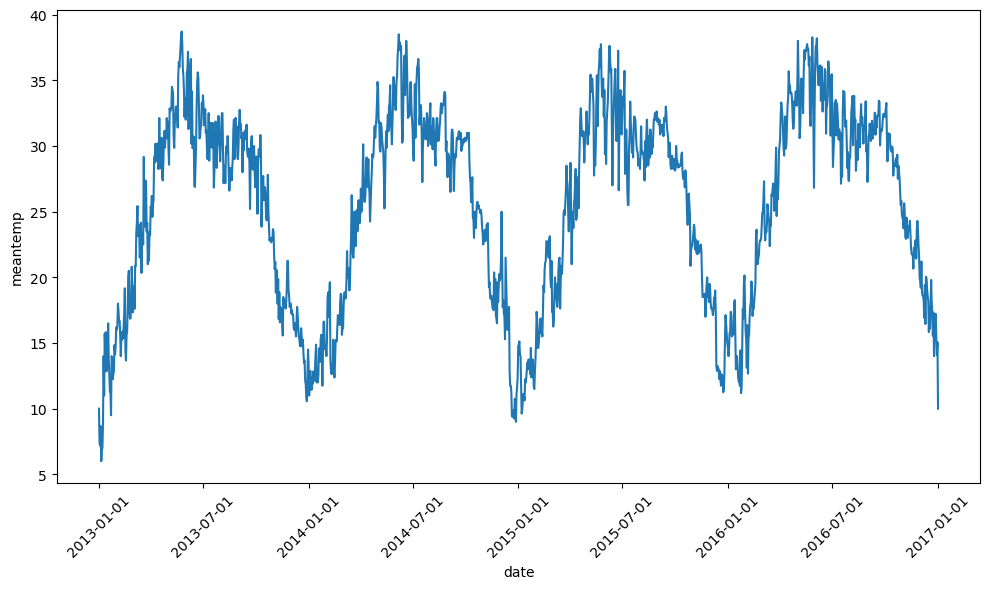

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(df_train, x='date', y='meantemp', ax=ax)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
df = df_train[['date','meantemp']]
df = df.set_index('date')
df = df.resample('W').sum()

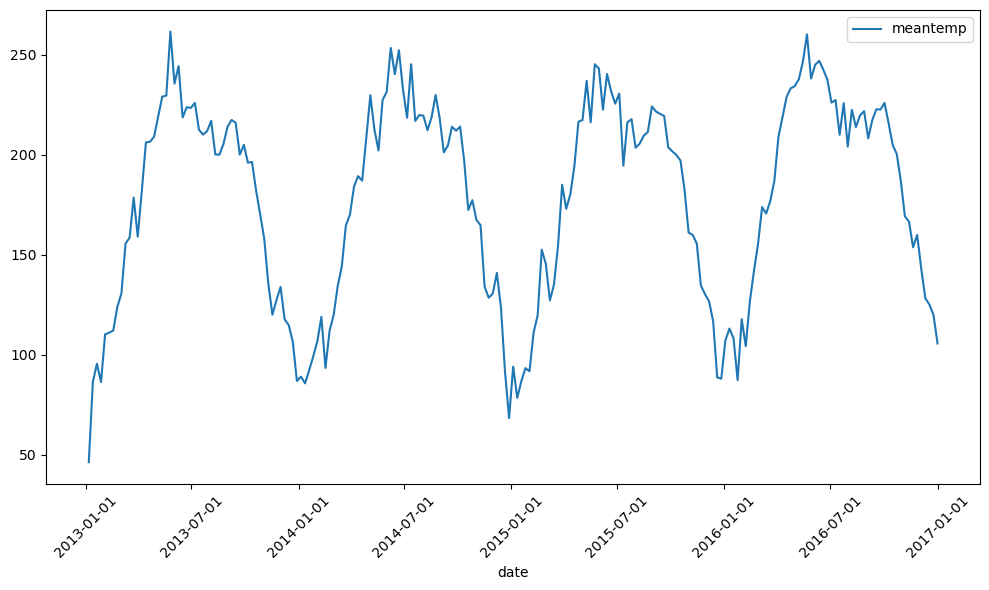

In [45]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(df, ax=ax)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Identify if there is a seasonality first:

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

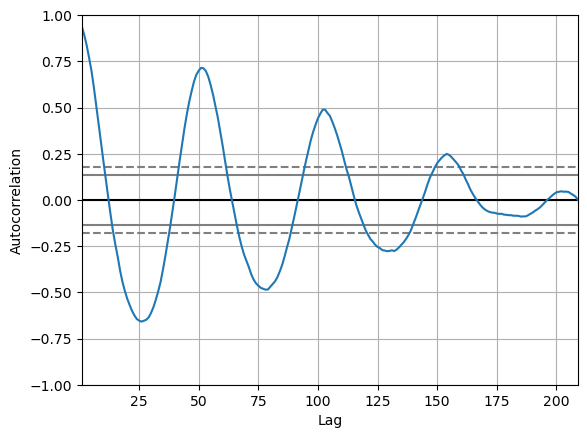

In [46]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(df['meantemp'])

Considering the above, it looks like there is a seasonality that repeats every 52 lags. Lets identify the ACF and PACF:

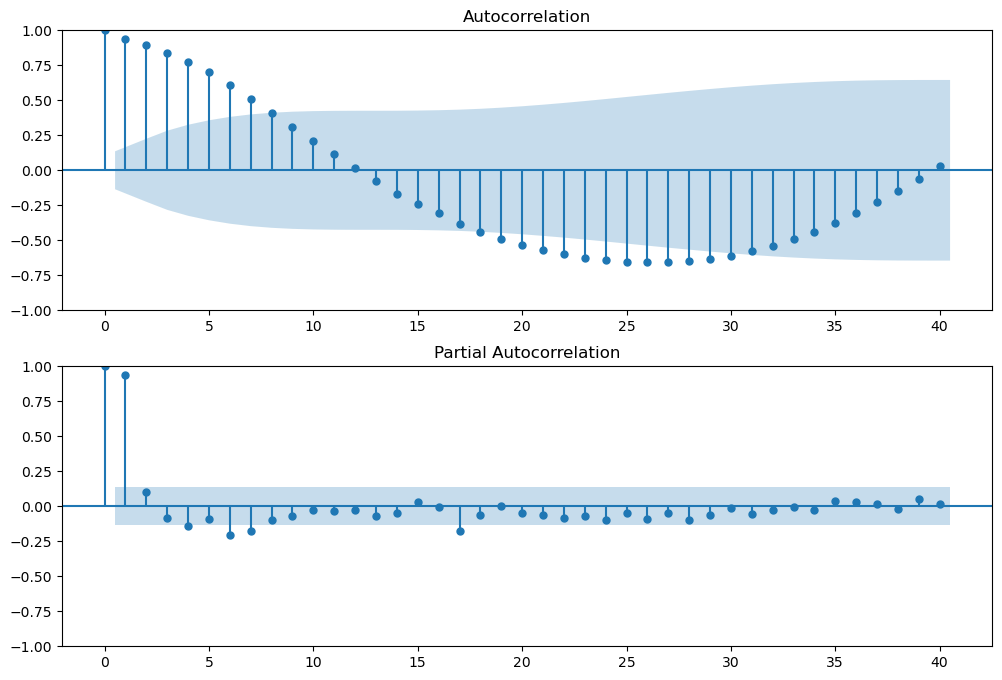

In [47]:
import statsmodels.api as sm
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(df['meantemp'], lags=40, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df['meantemp'], lags=40, ax=ax2)

ACF plots show the correlation between a time series and a lagged version of itself, decreasing exponentially. 

PACF plots show the correlation between a time series and a lagged version of itself after removing the effects of intervening observations. The PACF graph is abrupt after 2 views.

the next thing we need to do es identify the decomposition parts:

<Figure size 640x480 with 0 Axes>

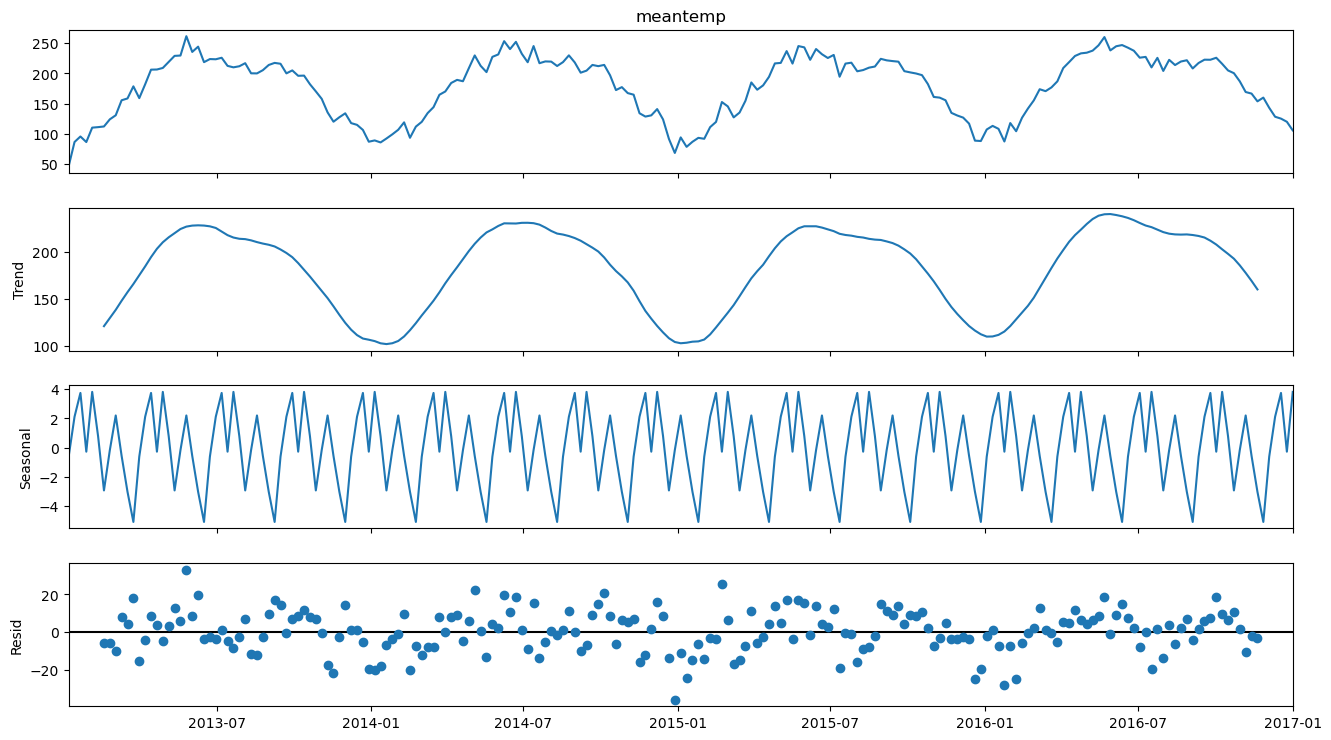

In [48]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['meantemp'], period=12)  
fig = plt.figure()  
fig = decomposition.plot()  
fig.set_size_inches(15, 8)

In [49]:
from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries):

    #Determing rolling statistics
    rolmean = timeseries.rolling(window=52).mean()
    rolstd = timeseries.rolling(window=52).std()

    #Plot rolling statistics:
    fig = plt.figure(figsize=(12, 8))
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show()
    
    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

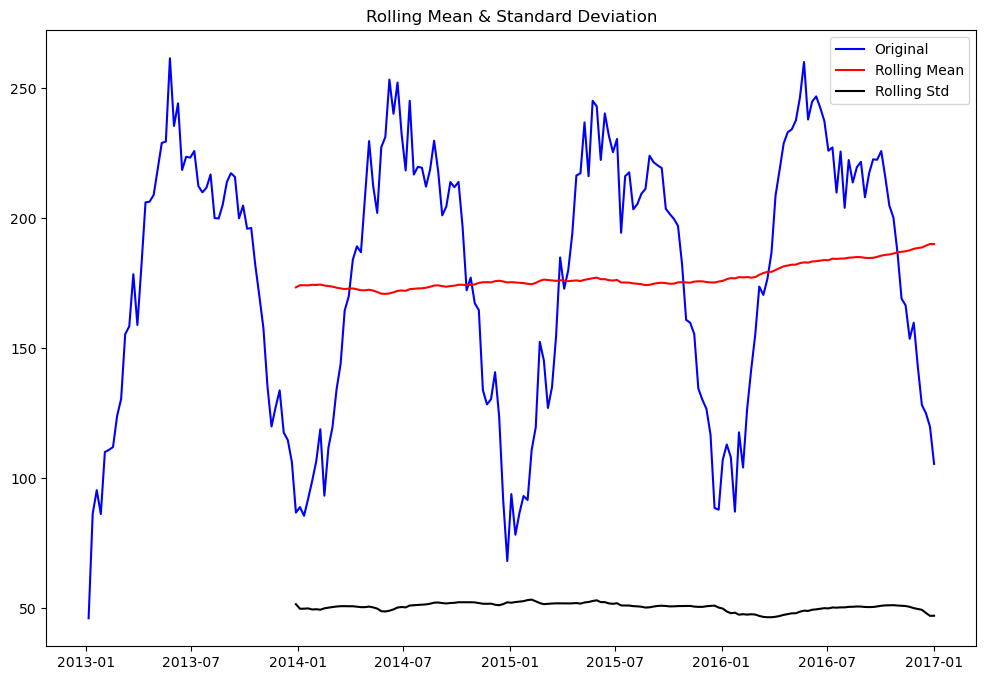

Results of Dickey-Fuller Test:
Test Statistic                  -4.726685
p-value                          0.000075
#Lags Used                       6.000000
Number of Observations Used    202.000000
Critical Value (1%)             -3.463144
Critical Value (5%)             -2.875957
Critical Value (10%)            -2.574455
dtype: float64


In [50]:
test_stationarity(df['meantemp'])

Since the results are showing the data is not stationary, we need to make it stationary by either differencing, log, square, cube root or proportional change

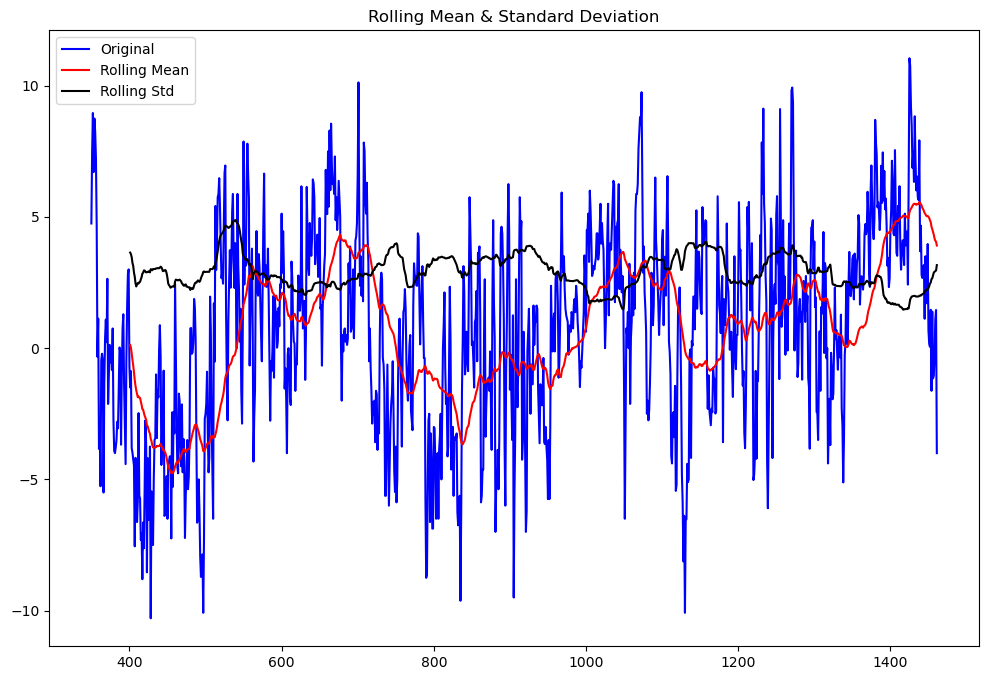

Results of Dickey-Fuller Test:
Test Statistic                   -4.005774
p-value                           0.001381
#Lags Used                       20.000000
Number of Observations Used    1091.000000
Critical Value (1%)              -3.436358
Critical Value (5%)              -2.864193
Critical Value (10%)             -2.568182
dtype: float64


In [13]:
df_firstdiff = df['meantemp'].diff(350) #taking the first difference
test_stationarity(df_firstdiff.dropna()) #testing the data to identify if it is stationary now

Now that the data is stationary, we can identify the p, d and q values to use for ARIMa. in order to do so we are going to use auto ARIMA

In [80]:
import pmdarima as pmd

model=pmd.auto_arima(df['meantemp'], exogenous = df.index.month, start_p=1,start_q=1,test='adf',m=52,seasonal=True,trace=True)

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,0,1)[52] intercept   : AIC=inf, Time=23.03 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=2236.612, Time=0.04 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=1710.926, Time=7.59 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=inf, Time=15.02 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=2778.043, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[52] intercept   : AIC=1716.275, Time=0.09 sec
 ARIMA(1,0,0)(2,0,0)[52] intercept   : AIC=1710.574, Time=51.83 sec
 ARIMA(1,0,0)(2,0,1)[52] intercept   : AIC=inf, Time=81.26 sec
 ARIMA(1,0,0)(1,0,1)[52] intercept   : AIC=inf, Time=19.04 sec
 ARIMA(0,0,0)(2,0,0)[52] intercept   : AIC=inf, Time=55.84 sec
 ARIMA(2,0,0)(2,0,0)[52] intercept   : AIC=1708.592, Time=72.78 sec
 ARIMA(2,0,0)(1,0,0)[52] intercept   : AIC=1710.161, Time=10.60 sec
 ARIMA(2,0,0)(2,0,1)[52] intercept   : AIC=inf, Time=85.34 sec
 ARIMA(2,0,0)(1,0,1)[52] intercept   : AIC=inf, Time=25.40 sec
 ARIMA(3,0,0)(2,0,0)[52] intercept   : AIC=1

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  209
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -855.138
Date:                Sun, 15 Feb 2026   AIC                           1716.275
Time:                        13:46:44   BIC                           1726.302
Sample:                    01-06-2013   HQIC                          1720.329
                         - 01-01-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      4.3459      2.256      1.927      0.054      -0.075       8.767
ar.L1          0.9716      0.015     64.967      0.000       0.942       1.001
sigma2       206.7366     22.495      9.190      0.000     162.647     250.826
===================================================================================
Ljung-Box (L1) (Q):                   0.95   Jarque-Bera (JB):                 1.29
Prob(Q):                              0.33   Prob(JB):                         0.53
Heteroskedasticity (H):               0.75   Skew:                            -0.01
Prob(H) (two-sided):                  0.23   Kurtosis:                         2.62
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

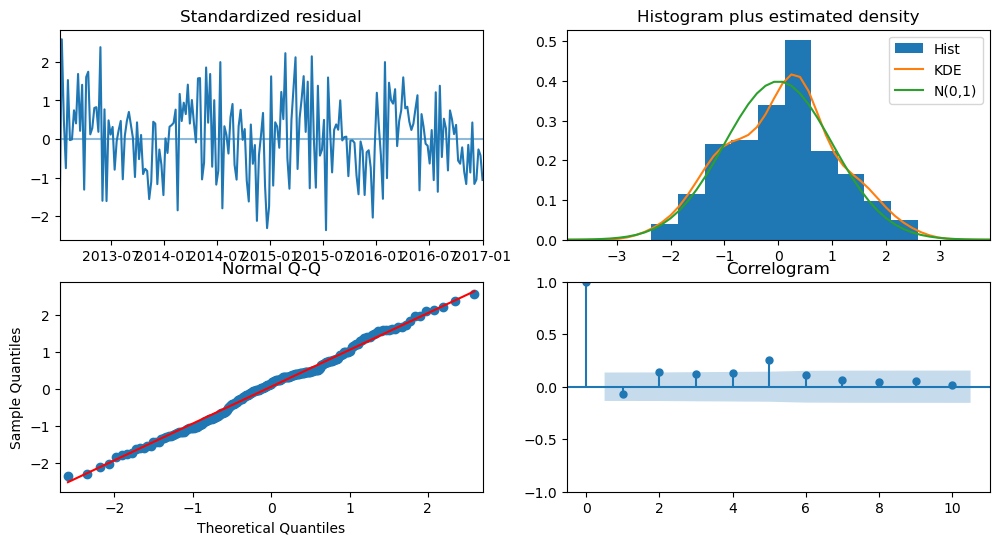

In [52]:
display(model.summary())
model.plot_diagnostics(figsize=(12,6));

We are looking for: 
<ul>
    <li>P > |z| (p-value) < 0.05</li>
    <li>Prob(Q) > 0.05 --> residues are white noise</li>
    <li>Prob(JB) > 0.05 residues normally distributed</li>
    <li>Prob(H) > 0.05 variance of residuals is constant over time</li>
</ul>


In [81]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
mod=SARIMAX(df['meantemp'],order=(2,0,0),seasonal_order=(2,0,0,52))
sarima = mod.fit()
predicted=sarima.predict();predicted

C:\Users\Alfredo.Hernandez\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


date
2013-01-06      0.000000
2013-01-13     45.987728
2013-01-20     79.395033
2013-01-27     93.423612
2013-02-03     87.260757
                 ...    
2016-12-04    158.897477
2016-12-11    140.225890
2016-12-18    117.789429
2016-12-25    119.139928
2017-01-01    127.746262
Freq: W-SUN, Name: predicted_mean, Length: 209, dtype: float64

In [82]:
df['pred'] = predicted

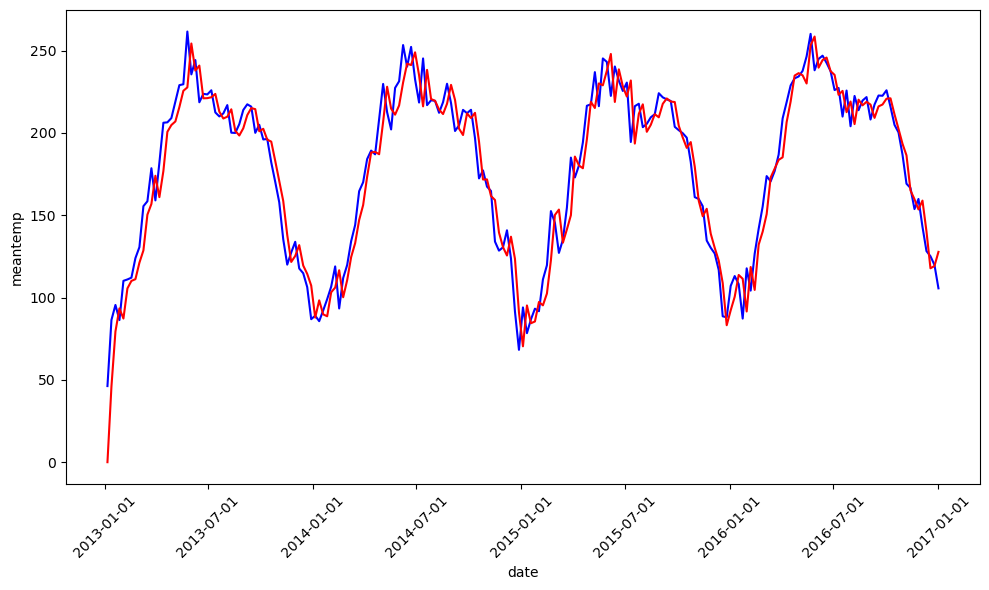

In [83]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(df['meantemp'], ax=ax, color='blue')
sns.lineplot(df['pred'], ax=ax, color='red')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [84]:
df.head()

,meantemp,pred
date,,
2013-01-06,46.233333,0.000000
2013-01-13,86.404762,45.987728
2013-01-20,95.500000,79.395033
2013-01-27,86.307143,93.423612
2013-02-03,110.158333,87.260757


In [85]:
def sarimax_forecast(SARIMAX_model, periods=350):
    # Forecast
    n_periods = periods

    fcst_indx = pd.date_range(df.index[-1], periods=n_periods, freq='MS')
    
    forecast_df = pd.DataFrame({"month_index": fcst_indx.month},
                               index=fcst_indx)

    fcst = SARIMAX_model.get_forecast(steps=n_periods,
                                            exog=forecast_df['month_index'])
    fitted = fcst.predicted_mean
    confint = fcst.conf_int(alpha = 0.05)

    # make series for plotting purpose
    fitted_series = pd.Series(fitted, index=fitted.index)
    lower_series = pd.Series(confint.iloc[:, 0], index=confint.index)
    upper_series = pd.Series(confint.iloc[:, 1], index=confint.index)

    # Plot
    plt.figure(figsize=(15, 7))
    plt.plot(df["meantemp"], color='#1f76b4')
    plt.plot(fitted_series, color='darkgreen')
    plt.fill_between(lower_series.index,
                     lower_series,
                     upper_series,
                     color='k', alpha=.15)

    plt.title("SARIMAX - Forecast of Airline Passengers")
    plt.show()

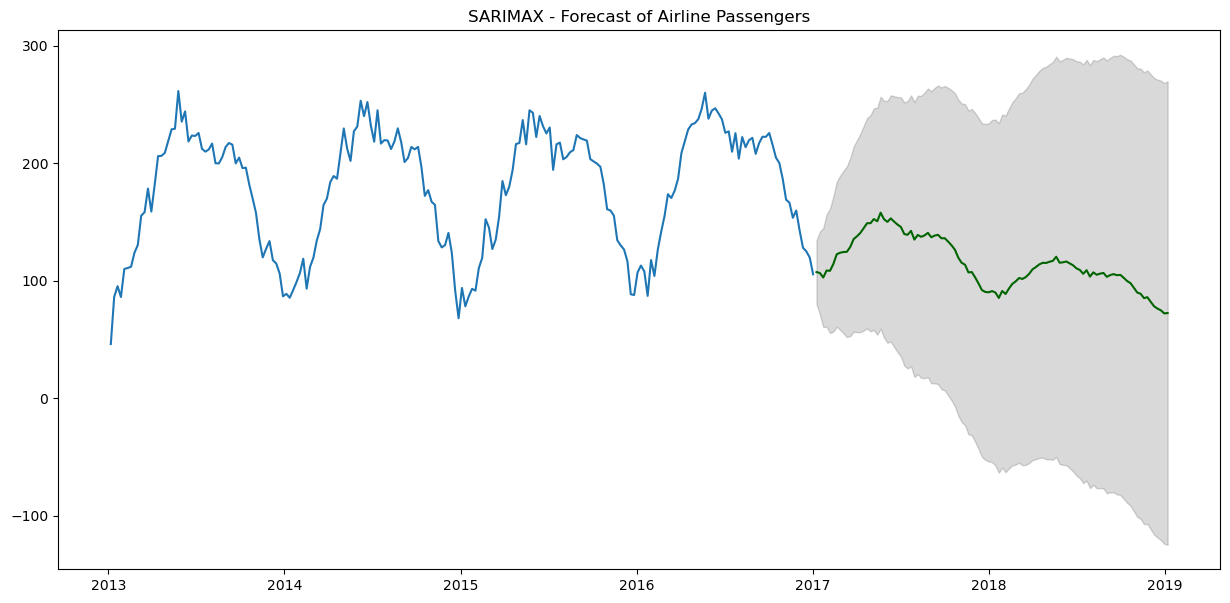

In [86]:
sarimax_forecast(sarima, 105)